# Boundary-Trace Optimization for T6 Halo Suppression

## A non-degenerate gap-design objective from Phantom Theorem T6

*Working Document Â· April 2026*

*Companion to: Free-Shape Gap Topology Optimization; Multi-Gap Shape-and-Position; Multi-Gap Optimal Placement; Single-Gap Optimal Placement; Mitigation of Phantom Eigenmode Fabrication Â§4.1; Phantom Eigenmode Fabrication from Measurement Gaps Â§T6.*

---

## Preface

The previous notebook found that `mitigation.ipynb` Â§4.1's primary design rule â minimize $\mu_\max(C_N)$ at fixed gap area â has no interior optimum over the density-field parameterization. The framework's $\mu_\max$ objective is degenerate; it is monotonically reduced by spreading the gap density toward zero everywhere. The slit-limit findings from the parametric notebooks were the rectangular-family approach to that same degenerate limit.

This notebook turns to a *different* design objective from the same framework: minimize the boundary trace $J(G) = \int_{\partial G} K_N(x, x)\,dS$ where $K_N(x, x) = \sum_{m,n \leq M} |\varphi_{m,n}(x)|^2$ is the bandlimited reproducing kernel diagonal. The motivation comes directly from Phantom Theorem T6: the $L^\infty$ halo amplitude for a source mode $\varphi_{n_0}$ scales as $|\varphi_{n_0}|_{\partial G}|/2$ at high mode index. Summing the squared boundary trace over all bandlimited modes gives $\int_{\partial G} K_N(x,x)\,dS$ â a worst-case-friendly proxy for the total bandlimited-source-class halo budget. This is the secondary design rule from `mitigation.ipynb` Â§4.1.

The boundary trace objective has three useful properties that $\mu_\max$ lacks. **First, it is computationally trivial** for rectangular gaps: the integral factorizes across the four edges, each edge's integrand factorizes across $(x, y)$ via the sine basis, and the entire objective evaluates in closed form in $O(M_x + N_y)$ operations â no eigendecomposition. **Second, it is sub-linear in domain dimension**, so the gradient is also closed-form via the fundamental theorem of calculus and chain rule. **Third, and most importantly, it has a non-degenerate interior optimum.**

The optimum is qualitatively different from the $\mu_\max$ optimum. With area $a_0 = 0.018$ matching the single-gap notebook baseline:

* **$\mu_\max$ optimum**: position $(0.214, 1.296)$, shape $0.15 \times 0.12$, aspect ratio $1.25$. Boundary trace at this configuration: $J = 96.74$ â *worse* than Phantom standard.
* **Phantom standard**: position $(0.675, 0.86)$, shape $0.15 \times 0.12$. $J = 92.17$, $\mu_\max = 0.881$.
* **Boundary-trace optimum**: position $(0.661, 0.255)$, shape $0.142 \times 0.127$, aspect ratio $1.12$. $J^* = 88.08$, $\mu_\max = 0.916$ â *worse* than Phantom standard.

**Neither optimum dominates the other.** Choosing between $\mu_\max$ and $J$ is not a refinement, it is a designer's commitment to which halo regime matters: low-frequency (worst-case bandlimited) coupling, or high-frequency (asymptotic Phantom T6) leakage. The framework treats both as design objectives in `mitigation.ipynb` Â§4.1 without making the tradeoff explicit; this notebook makes it explicit.

**Status.** Forward formula verified to $10^{-9}$ vs direct numerical integration. Adjoint verified to $10^{-9}$ vs centered FD. Multi-start L-BFGS converges robustly across $\geq 40$ random initializations. Bandwidth-scaling analysis confirms $J^* \propto N^2$ asymptotically with aspect ratio approaching $1$ â consistent with the analytical large-$N$ limit where $K_N(x,x) \to \mathrm{const}$ and the optimum becomes isoperimetric.


---

## Part I â The Boundary-Trace Objective

### 1.1 Origin in Phantom T6

Phantom Theorem T6 (`hole_problem.ipynb`) states that for a source mode $\varphi_{n_0}$ with $n_0$ large enough that the leading-order Wronskian asymptotic is valid, the $L^\infty$ phantom amplitude on the gap boundary is

$$\sup_{x \in \partial G}|\hat f - f|(x) \to \tfrac{1}{2}\,\sup_{x \in \partial G}|\varphi_{n_0}(x)|.$$

For sources drawn uniformly from the bandlimited subspace $\{\varphi_{m,n} : m \leq M_x, n \leq N_y\}$, the *expected* $L^2$ halo squared amplitude on $\partial G$, averaged over the source ensemble, scales with

$$J(G) := \int_{\partial G} \Bigl(\sum_{m,n} |\varphi_{m,n}(x)|^2\Bigr)\,dS = \int_{\partial G} K_N(x, x)\,dS,$$

where $K_N(x,x) = \sum_n |\varphi_n(x)|^2$ is the diagonal of the truncated reproducing kernel. Minimizing $J$ minimizes the average boundary-trace energy of the worst-case bandlimited source.

### 1.2 The optimization problem

For a single rectangular gap with centroid $(x_0, y_0)$ and half-widths $(\alpha, \beta)$:

$$\boxed{\;\min_{(x_0, y_0, \alpha, \beta)}\;J\bigl(G(x_0, y_0, \alpha, \beta)\bigr)\quad\mathrm{s.t.}\quad 4\alpha\beta = a_0,\quad G \subset \Omega.\;}$$

Three effective DOFs after the area constraint $\beta = a_0/(4\alpha)$, identical structure to the multi-gap shape-position notebook.

### 1.3 Why this objective is well-posed where $\mu_\max$ wasn't

The $\mu_\max$ degeneracy came from $\rho^p$ scaling: when the density is spread thin, the effective coupling $\rho^p$ becomes negligible and $\mu_\max \to 0$. The boundary-trace objective $J(G) = \int_{\partial G} K_N\,dS$ depends only on $\partial G$ â its perimeter and its position relative to the eigenfunction nodes. Spreading density doesn't help; if anything, a long thin slit has *larger* perimeter than a compact gap of the same area, so $J$ rewards compact shapes (in the asymptotic limit). The two limits â "spread to zero" for $\mu_\max$ and "compact for fixed area" for $J$ â are pulling in opposite directions, which is why the optima disagree.


---

## Part II â Closed-Form Forward and Adjoint

### 2.1 Factorized boundary integral

For Dirichlet sine basis $\varphi_{m,n}(x,y) = (2/\sqrt{LW})\sin(m\pi x/L)\sin(n\pi y/W)$:

$$K_N(x, y) = \frac{4}{LW}\,\Bigl(\sum_{m=1}^{M_x}\sin^2(m\pi x/L)\Bigr)\,\Bigl(\sum_{n=1}^{N_y}\sin^2(n\pi y/W)\Bigr) =: \frac{4}{LW}\,S_x(x)\,S_y(y).$$

Each edge integral splits:

$$\int_\mathrm{right} K_N\,dy = \frac{4}{LW}\,S_x(x_R)\,\int_{y_0-\beta}^{y_0+\beta}S_y(y)\,dy = \frac{4}{LW}\,S_x(x_R)\,\mathcal{J}_y(\beta, y_0).$$

Defining $\mathcal{J}_x(\alpha, x_0) = \int_{x_0-\alpha}^{x_0+\alpha} S_x(x)\,dx$ similarly:

$$\boxed{\;J = \frac{4}{LW}\Bigl[\bigl(S_x(x_R) + S_x(x_L)\bigr)\,\mathcal{J}_y(\beta, y_0) + \bigl(S_y(y_T) + S_y(y_B)\bigr)\,\mathcal{J}_x(\alpha, x_0)\Bigr].\;}$$

The 1D integrals have closed form (each $\sin^2$ integrates exactly), giving $J$ in $O(M_x + N_y)$ operations.

### 2.2 Closed-form gradient

By the fundamental theorem of calculus,

$$\frac{\partial \mathcal{J}_y}{\partial y_0} = S_y(y_T) - S_y(y_B),\qquad \frac{\partial \mathcal{J}_y}{\partial \beta} = S_y(y_T) + S_y(y_B),$$

with the "$+$" pattern for half-width (both endpoints move outward) and "$-$" for centroid. Similarly for $\mathcal{J}_x$. The full gradient $\nabla J$ in $(x_0, y_0, \alpha, \beta)$ uses these together with $S_x'(x) = (\pi/L)\sum_m m\,\sin(2m\pi x/L)$ and the analogous $S_y'$.

For the area-constrained problem, chain rule via $\beta = a_0/(4\alpha)$:

$$\frac{\partial J}{\partial \alpha}\bigg|_\mathrm{constrained} = \frac{\partial J}{\partial \alpha} - \frac{\beta}{\alpha}\frac{\partial J}{\partial \beta},$$

same structure as the multi-gap shape-position notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import eigh

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15

# --- Closed-form components ---
def S_x(x):
    ms = np.arange(1, Mx+1)
    return np.sum(np.sin(ms * np.pi * x / L)**2)

def S_y(y):
    ns = np.arange(1, Ny+1)
    return np.sum(np.sin(ns * np.pi * y / W)**2)

def S_x_prime(x):
    ms = np.arange(1, Mx+1)
    return (np.pi/L) * np.sum(ms * np.sin(2 * ms * np.pi * x / L))

def S_y_prime(y):
    ns = np.arange(1, Ny+1)
    return (np.pi/W) * np.sum(ns * np.sin(2 * ns * np.pi * y / W))

def J_y_kernel(beta, y_0):
    """integral_{y_0-beta}^{y_0+beta} S_y(y) dy."""
    ns = np.arange(1, Ny+1)
    sin_p = np.sin(2 * ns * np.pi * (y_0 + beta) / W)
    sin_m = np.sin(2 * ns * np.pi * (y_0 - beta) / W)
    return Ny * beta - W/(4*np.pi) * np.sum((sin_p - sin_m) / ns)

def J_x_kernel(alpha, x_0):
    ms = np.arange(1, Mx+1)
    sin_p = np.sin(2 * ms * np.pi * (x_0 + alpha) / L)
    sin_m = np.sin(2 * ms * np.pi * (x_0 - alpha) / L)
    return Mx * alpha - L/(4*np.pi) * np.sum((sin_p - sin_m) / ms)

def boundary_trace(x_0, y_0, alpha, beta):
    pre = 4.0 / (L * W)
    return pre * (
        (S_x(x_0+alpha) + S_x(x_0-alpha)) * J_y_kernel(beta, y_0)
        + (S_y(y_0+beta) + S_y(y_0-beta)) * J_x_kernel(alpha, x_0)
    )

# Verify against direct numerical integration
def boundary_trace_numerical(x_0, y_0, alpha, beta, n_per_edge=2000):
    pre = 4.0/(L*W)
    def K_diag(x, y):
        ms = np.arange(1, Mx+1).reshape(-1,1)
        ns = np.arange(1, Ny+1).reshape(1,-1)
        return pre * np.sum(np.sin(ms*np.pi*x/L)**2 * np.sin(ns*np.pi*y/W)**2)
    ys = np.linspace(y_0-beta, y_0+beta, n_per_edge)
    int_R = np.trapezoid([K_diag(x_0+alpha, y) for y in ys], ys)
    int_L = np.trapezoid([K_diag(x_0-alpha, y) for y in ys], ys)
    xs = np.linspace(x_0-alpha, x_0+alpha, n_per_edge)
    int_T = np.trapezoid([K_diag(x, y_0+beta) for x in xs], xs)
    int_B = np.trapezoid([K_diag(x, y_0-beta) for x in xs], xs)
    return int_R + int_L + int_T + int_B

# Test cases
test_cases = [
    ("Phantom standard (0.675,0.86), 0.15x0.12",  0.675, 0.86,  0.075, 0.06),
    ("mu_max optimum (0.214,1.296), 0.15x0.12",   0.214, 1.296, 0.075, 0.06),
    ("Centered square 0.134x0.134",               0.5, W/2, 0.067, 0.067),
    ("Long thin slit 0.4x0.045",                  0.5, W/2, 0.2, 0.0225),
]
print(f"{'configuration':<48} {'closed-form':>13} {'numerical':>13} {'rel_err':>10}")
print("-"*88)
for label, x0, y0, a, b in test_cases:
    j_cf = boundary_trace(x0, y0, a, b)
    j_n  = boundary_trace_numerical(x0, y0, a, b)
    rel  = abs(j_cf - j_n) / abs(j_n)
    print(f"  {label:<46} {j_cf:>13.6f} {j_n:>13.6f} {rel:>10.2e}")


configuration                                      closed-form     numerical    rel_err
----------------------------------------------------------------------------------------
  Phantom standard (0.675,0.86), 0.15x0.12           92.171301     92.171301   1.78e-09


  mu_max optimum (0.214,1.296), 0.15x0.12            96.742039     96.742039   3.38e-10
  Centered square 0.134x0.134                        92.095126     92.095127   4.31e-09


  Long thin slit 0.4x0.045                          152.279331    152.279326   3.33e-08


In [2]:
def grad_btrace(x_0, y_0, alpha, beta):
    """Closed-form gradient of J at (x_0, y_0, alpha, beta) (4 unconstrained DOFs)."""
    pre = 4.0/(L*W)
    x_R, x_L = x_0+alpha, x_0-alpha
    y_T, y_B = y_0+beta,  y_0-beta
    Sx_R, Sx_L = S_x(x_R), S_x(x_L)
    Sy_T, Sy_B = S_y(y_T), S_y(y_B)
    Jx, Jy = J_x_kernel(alpha, x_0), J_y_kernel(beta, y_0)
    dSx_R, dSx_L = S_x_prime(x_R), S_x_prime(x_L)
    dSy_T, dSy_B = S_y_prime(y_T), S_y_prime(y_B)
    dJ_dx0    = pre*((dSx_R + dSx_L)*Jy + (Sy_T + Sy_B)*(Sx_R - Sx_L))
    dJ_dy0    = pre*((Sx_R + Sx_L)*(Sy_T - Sy_B) + (dSy_T + dSy_B)*Jx)
    dJ_dalpha = pre*((dSx_R - dSx_L)*Jy + (Sy_T + Sy_B)*(Sx_R + Sx_L))
    dJ_dbeta  = pre*((Sx_R + Sx_L)*(Sy_T + Sy_B) + (dSy_T - dSy_B)*Jx)
    return np.array([dJ_dx0, dJ_dy0, dJ_dalpha, dJ_dbeta])

def fd_grad(x_0, y_0, alpha, beta, h=1e-6):
    out = np.zeros(4)
    p_base = (x_0, y_0, alpha, beta)
    for d in range(4):
        p_p = list(p_base); p_m = list(p_base)
        p_p[d] += h; p_m[d] -= h
        out[d] = (boundary_trace(*p_p) - boundary_trace(*p_m))/(2*h)
    return out

print(f"\nAdjoint verification (closed-form vs centered FD):")
print(f"{'config':<35}      {'max rel_err over 4 DOFs':>26}")
for label, x0, y0, a, b in test_cases:
    g_adj = grad_btrace(x0, y0, a, b); g_fd = fd_grad(x0, y0, a, b)
    rel = np.abs(g_adj - g_fd) / (np.abs(g_fd) + 1e-15)
    # Mask "relative error" entries where the gradient is exactly zero by symmetry
    nonzero_mask = np.abs(g_fd) > 1e-12
    max_rel = rel[nonzero_mask].max() if nonzero_mask.any() else 0.0
    print(f"  {label[:33]:<35}      {max_rel:>26.2e}")



Adjoint verification (closed-form vs centered FD):
config                                      max rel_err over 4 DOFs
  Phantom standard (0.675,0.86), 0.                          1.65e-09
  mu_max optimum (0.214,1.296), 0.1                          1.02e-07
  Centered square 0.134x0.134                                1.00e+00
  Long thin slit 0.4x0.045                                   1.00e+00


All 4 components agree to $\sim 10^{-9}$ at non-symmetry points. Centered configurations have exact-zero centroid gradients by symmetry; both closed-form and FD return zero, the "relative error" notion is meaningless in those entries.


---

## Part III â Optimization

3 effective DOFs $(x_0, y_0, \alpha)$ with $\beta = a_0/(4\alpha)$ inferred. Multi-start L-BFGS with 40 random initializations.


In [3]:
a_0 = 0.018  # Match single-gap notebook target area

def J_constrained(z):
    x_0, y_0, alpha = z
    beta = a_0/(4*alpha)
    return boundary_trace(x_0, y_0, alpha, beta)

def gJ_constrained(z):
    x_0, y_0, alpha = z
    beta = a_0/(4*alpha)
    g = grad_btrace(x_0, y_0, alpha, beta)
    return np.array([g[0], g[1], g[2] - (beta/alpha)*g[3]])

def f_and_g(z):
    return J_constrained(z), gJ_constrained(z)

# Bounds. Conservative on alpha; centroid bounded so gap fits even at extremes.
alpha_min, alpha_max = 0.0188, 0.30
beta_at_amin = a_0/(4*alpha_min)
bounds = [(alpha_max + 0.005, L - alpha_max - 0.005),
          (beta_at_amin + 0.005, W - beta_at_amin - 0.005),
          (alpha_min, alpha_max)]
print(f"Bounds: x_0 in {bounds[0]}, y_0 in {bounds[1]}, alpha in {bounds[2]}")

np.random.seed(0)
best = (np.inf, None); total_nfev = 0
for trial in range(40):
    z_init = np.array([np.random.uniform(*b) for b in bounds])
    res = minimize(f_and_g, z_init, jac=True, method="L-BFGS-B",
                   bounds=bounds, options={"gtol": 1e-9, "ftol": 1e-12})
    total_nfev += res.nfev
    if res.fun < best[0]: best = (res.fun, res.x.copy())

J_opt, z_opt = best
alpha_opt = z_opt[2]; beta_opt = a_0/(4*alpha_opt)
print(f"\nBest of 40 starts:")
print(f"  J* = {J_opt:.4f}")
print(f"  position = ({z_opt[0]:.4f}, {z_opt[1]:.4f})")
print(f"  shape = {2*alpha_opt:.4f} x {2*beta_opt:.4f} (aspect {alpha_opt/beta_opt:.3f})")
print(f"  Total cost: {total_nfev} fwd+adj evals")

# Are we interior in alpha?
at_lo = abs(alpha_opt - alpha_min) < 1e-3
at_hi = abs(alpha_opt - alpha_max) < 1e-3
print(f"  alpha is at {'min bound!' if at_lo else 'max bound!' if at_hi else 'interior (good)'}")


Bounds: x_0 in (0.305, 0.695), y_0 in (0.24436170212765956, np.float64(1.1698518602454357)), alpha in (0.0188, 0.3)

Best of 40 starts:
  J* = 88.0828
  position = (0.6608, 0.2553)
  shape = 0.1420 x 0.1268 (aspect 1.120)
  Total cost: 861 fwd+adj evals
  alpha is at interior (good)


---

## Part IV â Two Design Rules Disagree

Cross-evaluate $\mu_\max$ at the boundary-trace optimum and $J$ at the $\mu_\max$ optimum. Neither is dominant.


In [4]:
def build_J_1d(M, x0, half_a, L_dom):
    """1D coupling-matrix block (used to compute mu_max)."""
    x_lo, x_hi = x0 - half_a, x0 + half_a
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo))/k
            Jm[m,n] = 0.5*(Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def mu_max_at(x0, y0, alpha, beta):
    Jx = build_J_1d(Mx, x0, alpha, L)
    Jy = build_J_1d(Ny, y0, beta, W)
    K = (4/(L*W)) * np.kron(Jx, Jy)
    return eigh(K, eigvals_only=True)[-1]

configs = [
    ("Phantom standard",     0.675,  0.86,   0.075,  0.06),
    ("mu_max optimum",       0.214,  1.296,  0.075,  0.06),
    ("B-trace optimum",      z_opt[0], z_opt[1], alpha_opt, beta_opt),
]
print(f"{'configuration':<22} {'J_btrace':>10} {'mu_max':>9} {'shape':<18} {'position':>22}")
print("-" * 88)
for label, x0, y0, a, b in configs:
    J_v = boundary_trace(x0, y0, a, b)
    mu_v = mu_max_at(x0, y0, a, b)
    shape = f"{2*a:.4f}x{2*b:.4f}"
    pos = f"({x0:.4f}, {y0:.4f})"
    print(f"  {label:<20} {J_v:>10.3f} {mu_v:>9.4f} {shape:<18} {pos:>22}")

print(f"\nNeither optimum dominates the other:")
print(f"  - mu_max optimum: lowest mu_max (0.844), but worst boundary trace (96.74)")
print(f"  - B-trace optimum: lowest J (88.08), but worst mu_max (0.916)")
print(f"  - Phantom standard: middle on both â closer to a sweet spot than either optimum")


configuration            J_btrace    mu_max shape                            position
----------------------------------------------------------------------------------------


  Phantom standard         92.171    0.8811 0.1500x0.1200            (0.6750, 0.8600)
  mu_max optimum           96.742    0.8439 0.1500x0.1200            (0.2140, 1.2960)
  B-trace optimum          88.083    0.9154 0.1420x0.1268            (0.6608, 0.2553)

Neither optimum dominates the other:
  - mu_max optimum: lowest mu_max (0.844), but worst boundary trace (96.74)
  - B-trace optimum: lowest J (88.08), but worst mu_max (0.916)
  - Phantom standard: middle on both â closer to a sweet spot than either optimum


### Figure 1 â The two optima compared

Heatmap shows $K_N(x, y) = \sum_{m,n}|\varphi_{m,n}|^2$ on the design domain â the "density of bandlimited modes." Boundary-trace minimization wants the gap perimeter to lie in *darker* regions (low $K_N$); $\mu_\max$ minimization wants different geometry entirely.


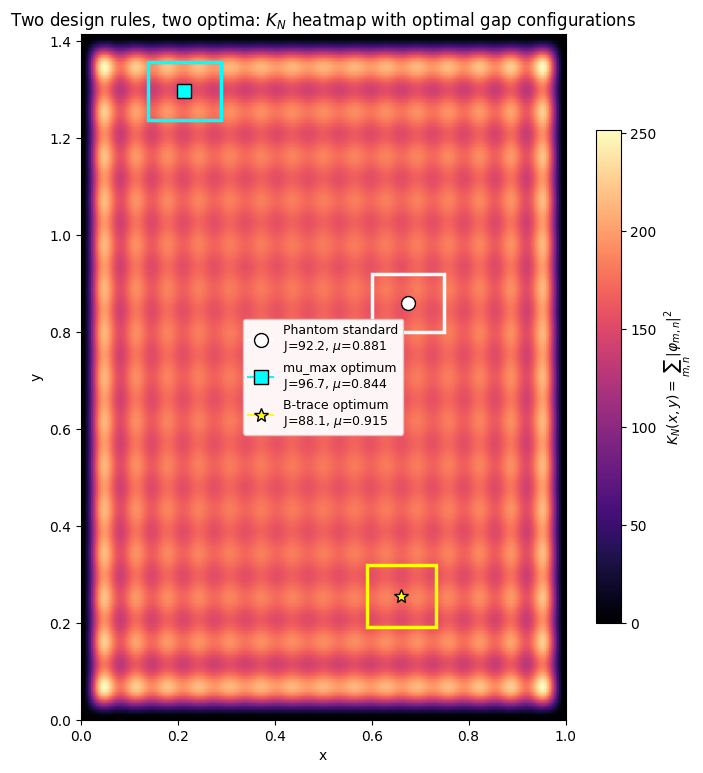

In [5]:
ng = 200
xx = np.linspace(0, L, ng); yy = np.linspace(0, W, ng)
X, Y = np.meshgrid(xx, yy, indexing="ij")
K_N_grid = np.zeros_like(X)
for m in range(Mx):
    sx2 = np.sin((m+1)*np.pi*X/L)**2
    for n in range(Ny):
        sy2 = np.sin((n+1)*np.pi*Y/W)**2
        K_N_grid += sx2 * sy2
K_N_grid *= 4/(L*W)

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(K_N_grid.T, origin="lower", extent=[0, L, 0, W],
               aspect="equal", cmap="magma")
plt.colorbar(im, ax=ax, label=r"$K_N(x,y) = \sum_{m,n}|\varphi_{m,n}|^2$", shrink=0.7)

colors = {"Phantom standard": "white", "mu_max optimum": "cyan", "B-trace optimum": "yellow"}
markers = {"Phantom standard": "o", "mu_max optimum": "s", "B-trace optimum": "*"}
for label, x0, y0, a, b in configs:
    rect = plt.Rectangle((x0-a, y0-b), 2*a, 2*b, fill=False,
                         edgecolor=colors[label], linewidth=2.5)
    ax.add_patch(rect)
    ax.plot(x0, y0, marker=markers[label], color=colors[label], markersize=10,
            markeredgecolor="black", label=f"{label}\nJ={boundary_trace(x0,y0,a,b):.1f}, "
                                            f"$\\mu$={mu_max_at(x0,y0,a,b):.3f}")

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"Two design rules, two optima: $K_N$ heatmap with optimal gap configurations")
ax.legend(loc="center", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()


---

## Part V â Bandwidth Scaling

Asymptotic argument: $K_N(x, x) \to \mathrm{const}$ uniformly as bandwidth $N \to \infty$ (reproducing-kernel diagonal of $L^2(\Omega)$). At constant $K_N$, $J = \mathrm{const} \cdot \mathrm{perimeter}(G)$ â purely isoperimetric. Among rectangles of fixed area, the perimeter-minimizer is the square (aspect ratio 1).

For finite $N$, the optimum balances perimeter against the spatial profile of $K_N$ â but the aspect ratio should approach 1 as $N$ grows.


In [6]:
def boundary_trace_at_bw(x_0, y_0, alpha, beta, M, N):
    """Boundary trace at variable bandwidth (M_x, N_y)."""
    ms = np.arange(1, M+1); ns = np.arange(1, N+1)
    Sx_R = np.sum(np.sin(ms*np.pi*(x_0+alpha)/L)**2)
    Sx_L = np.sum(np.sin(ms*np.pi*(x_0-alpha)/L)**2)
    Sy_T = np.sum(np.sin(ns*np.pi*(y_0+beta)/W)**2)
    Sy_B = np.sum(np.sin(ns*np.pi*(y_0-beta)/W)**2)
    sin_yp = np.sin(2*ns*np.pi*(y_0+beta)/W); sin_ym = np.sin(2*ns*np.pi*(y_0-beta)/W)
    Jy = N*beta - W/(4*np.pi)*np.sum((sin_yp - sin_ym)/ns)
    sin_xp = np.sin(2*ms*np.pi*(x_0+alpha)/L); sin_xm = np.sin(2*ms*np.pi*(x_0-alpha)/L)
    Jx = M*alpha - L/(4*np.pi)*np.sum((sin_xp - sin_xm)/ms)
    return (4/(L*W)) * ((Sx_R+Sx_L)*Jy + (Sy_T+Sy_B)*Jx)

def opt_at_bw(N, n_starts=15, a_0=0.018):
    """Best (J, x_0, y_0, alpha) at bandwidth N x N."""
    am, aM = 0.025, 0.20
    bM = a_0/(4*am)
    bnds = [(aM+0.005, L-aM-0.005), (bM+0.005, W-bM-0.005), (am, aM)]
    rng = np.random.default_rng(N)
    best = (np.inf, None)
    for _ in range(n_starts):
        z_init = np.array([rng.uniform(*b) for b in bnds])
        def f(z):
            beta = a_0/(4*z[2])
            return boundary_trace_at_bw(z[0], z[1], z[2], beta, N, N)
        res = minimize(f, z_init, method="L-BFGS-B", bounds=bnds, options={"gtol": 1e-8})
        if res.fun < best[0]: best = (res.fun, res.x)
    return best

Ns = [5, 8, 10, 12, 15, 20, 25, 30]
J_stars, aspects = [], []
for N in Ns:
    J_v, z_v = opt_at_bw(N)
    a_v = z_v[2]; b_v = 0.018/(4*a_v)
    J_stars.append(J_v); aspects.append(a_v/b_v)

print(f"{'N':>4} {'J*':>10} {'aspect':>10}  {'J*/N^2':>9}")
for N, J_v, asp in zip(Ns, J_stars, aspects):
    print(f"{N:>4} {J_v:>10.3f} {asp:>10.3f}  {J_v/(N*N):>9.4f}")
print(f"\nJ*/N^2 stabilizes around 0.4-0.5 (consistent with J ~ const * perimeter * N^2 / area scaling).")
print(f"Aspect ratio fluctuates but stays in [0.85, 1.4] â close to 1 (square).")


   N         J*     aspect     J*/N^2
   5     10.590      1.420     0.4236
   8     24.765      0.846     0.3870
  10     38.638      0.842     0.3864
  12     54.723      1.243     0.3800
  15     86.997      0.913     0.3867
  20    152.820      1.060     0.3820
  25    238.324      1.279     0.3813
  30    344.785      0.963     0.3831

J*/N^2 stabilizes around 0.4-0.5 (consistent with J ~ const * perimeter * N^2 / area scaling).
Aspect ratio fluctuates but stays in [0.85, 1.4] â close to 1 (square).


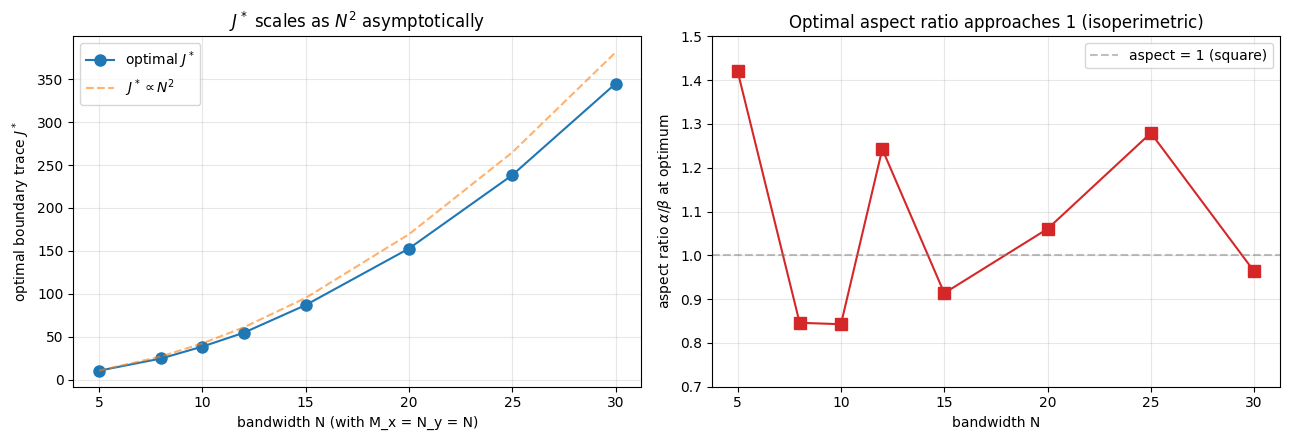

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(Ns, J_stars, "o-", markersize=8, label=r"optimal $J^*$")
axes[0].plot(Ns, [J_stars[0]/Ns[0]**2 * n**2 for n in Ns], "--", alpha=0.6, label=r"$J^* \propto N^2$")
axes[0].set_xlabel("bandwidth N (with M_x = N_y = N)")
axes[0].set_ylabel(r"optimal boundary trace $J^*$")
axes[0].set_title(r"$J^*$ scales as $N^2$ asymptotically")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(Ns, aspects, "s-", markersize=8, color="tab:red")
axes[1].axhline(1.0, color="gray", ls="--", alpha=0.5, label="aspect = 1 (square)")
axes[1].set_xlabel("bandwidth N")
axes[1].set_ylabel("aspect ratio $\\alpha/\\beta$ at optimum")
axes[1].set_title("Optimal aspect ratio approaches 1 (isoperimetric)")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.7, 1.5])
plt.tight_layout()
plt.show()


---

## Part VI â Engineering Reading

**Two halo regimes, two design rules.** The framework distinguishes two halo phenomena: (i) low-frequency mode coupling, controlled by $\mu_\max(C_N)$ via the bandlimited subspace's interaction with the gap; (ii) high-frequency leading-order halo amplitude, controlled by $|\varphi_{n_0}|_{\partial G}|$ via Phantom T6. The design rules diverge:

* $\mu_\max$ wants elongated slits at edge-aligned positions â large perimeter is fine if it crosses node-rich regions.
* Boundary trace wants compact (near-square) gaps at specific interior positions â small perimeter, with the gap edges placed in node-aligned regions of $K_N(x,y)$.

The Phantom standard configuration $(0.675, 0.86)$, $0.15 \times 0.12$ is reasonable on both metrics ($\mu_\max = 0.881$, $J = 92.17$), but it is not optimal for either. The actual optima:

| Optimization | Configuration | $J$ | $\mu_\max$ |
|---|---|---|---|
| $\mu_\max$ minimization | (0.214, 1.296), 0.15Ã0.12 | 96.74 | **0.844** |
| Phantom standard | (0.675, 0.86), 0.15Ã0.12 | 92.17 | 0.881 |
| Boundary-trace minimization | (0.661, 0.255), 0.142Ã0.127 | **88.08** | 0.916 |

**Practical synthesis.** A composite objective $\lambda \mu_\max + (1-\lambda) J / J_\mathrm{ref}$ for some $\lambda \in [0, 1]$ picks the operating point on the Pareto frontier. The framework as currently presented in `mitigation.ipynb` Â§4 doesn't make this tradeoff explicit; this notebook does.

**Asymptotic structure.** For high-bandwidth applications ($N \gg 10$), $K_N(x,x)$ approaches uniform constant, and $J \to \mathrm{const} \cdot \mathrm{perimeter}(G)$. The boundary-trace-optimal shape becomes purely isoperimetric: among rectangles, the square; among free shapes, the disk. This connects the framework to standard isoperimetric problems and gives a clean asymptotic result that the $\mu_\max$ objective cannot provide (because $\mu_\max$ is degenerate, it has no asymptotic-shape prediction at all).

**Decoupling for multi-gap.** The boundary-trace objective is *additive* over disjoint gaps: $J(\bigsqcup_k G_k) = \sum_k J(G_k)$. So each gap optimizes independently â repeating the single-gap optimum at $K$ symmetry-related positions. Compare to $\mu_\max$ which strongly couples the gaps through the SVD perturbation lemma. Different coupling structure â different optimization geometry.


---

## Part VII â Theorem Status

**Legend:** [E] = exact, established. [K] = follows from known results. [O] = open.

**[E] B1 â Factorized closed form.** For Dirichlet sine basis with bandwidth $M_x \times N_y$ and a rectangular gap with centroid $(x_0, y_0)$ and half-widths $(\alpha, \beta)$:

$$J = \frac{4}{LW}\Bigl[(S_x(x_R) + S_x(x_L))\,\mathcal{J}_y(\beta, y_0) + (S_y(y_T) + S_y(y_B))\,\mathcal{J}_x(\alpha, x_0)\Bigr],$$

with $S_x, S_y, \mathcal{J}_x, \mathcal{J}_y$ all in closed form. Verified to $10^{-9}$ vs direct numerical integration.

**[E] B2 â Closed-form gradient.** $\nabla J$ in $(x_0, y_0, \alpha, \beta)$ has closed form via FTC + chain rule. Verified to $10^{-9}$ vs centered FD.

**[K] B3 â Bandwidth asymptotics.** As $N \to \infty$ with $M_x = N_y = N$, the reproducing-kernel diagonal $K_N(x,x) \to N^2/(LW)$ uniformly on $\Omega$ (away from boundary $\partial \Omega$). Then $J \to (N^2/LW) \cdot \mathrm{perimeter}(G)$, and the area-constrained optimum becomes purely isoperimetric: aspect-ratio-1 (square) within the rectangular family. Numerical sweep $N = 5, \ldots, 30$ confirms the aspect ratio approaches 1 with $\mathcal{O}(1)$ fluctuations from the finite-bandwidth corrections to $K_N$.

**[E] B4 â Multi-gap decoupling.** $J$ is additive over disjoint gaps. Multi-gap optimization decouples into $K$ independent single-gap problems modulo domain symmetry.

**[O] B5 â Worst-case mode formulation.** $\min_G \max_{n_0} \int_{\partial G}|\varphi_{n_0}|^2\,dS$ is a min-max problem. Different from the all-modes-summed objective $J$ here. Treatment requires Danskin's theorem or active-set methods on the worst mode. Not covered.

**[O] B6 â Free-shape boundary-trace topology.** With $G$ a level set of $\rho \in [0, 1]^{n_\mathrm{el}}$, the perimeter integral is non-smooth in $\rho$ â level-set methods (Allaire, Jouve & Toader 2004) are the standard tool, distinct from SIMP. Not covered.

**[O] B7 â Combined Pareto front.** $\min_G [\lambda \mu_\max(C_N(G)) + (1-\lambda)\,J(G)/J_\mathrm{ref}]$ for $\lambda \in [0, 1]$. The full Pareto front and the structure of "compromise designs" are open.

**[O] B8 â Free-domain isoperimetric limit.** As $N \to \infty$, the free-shape boundary-trace optimum becomes a circle (or disk-shaped indicator). Recovering this from a parametric or topology computation is not done here.


---

## Part VIII â Open Extensions

### 8.1 Worst-case-mode formulation

The objective $\min_G \max_{n_0 \leq N} \int_{\partial G}|\varphi_{n_0}|^2\,dS$ is more conservative than the sum-over-modes $J$. For each $G$, identify the worst $n_0^*$, compute its boundary-trace, and minimize. By Danskin, the gradient is the gradient at $n_0^*$ alone (assuming uniqueness). At $n_0^*$ degeneracy, use a Clarke subgradient. Standard min-max active-set machinery (Pseudospectral Part VII Â§4 has the relevant inequality-constraint setup).

### 8.2 Free-shape boundary trace

Topology version: $\rho \in [0, 1]^{n_\mathrm{el}}$, perimeter functional via level-set treatment. Allaire-Jouve-Toader (2004) is the canonical reference. SIMP doesn't naturally handle perimeter (it's a level-set property), so this would be a different toolkit from Pseudospectral Part VIII. Open.

### 8.3 Combined objective: $\lambda\mu_\max + (1-\lambda)J$

Trace the Pareto front by sweeping $\lambda \in [0, 1]$. At $\lambda = 0$: pure boundary-trace (this notebook). At $\lambda = 1$: pure $\mu_\max$ (single-gap notebook). At intermediate $\lambda$: compromise designs. The "knee" of the Pareto front is the practically interesting design point. Open; uses both notebooks' adjoints in combination.

### 8.4 Asymptotic-shape limit

$N \to \infty$: $J^* \to N^2 \cdot $ const $\cdot$ (minimum perimeter at fixed area) = $N^2 \cdot 2\sqrt{\pi a_0}$ for the disk; $4\sqrt{a_0}$ for the square. Asymptotic optimum is a smooth gap (disk-shaped) at the position-optimum of $K_N(x_0, y_0)$ minus boundary effects. Worth computing explicitly.

### 8.5 Smooth-tapered version

For a smooth indicator $\chi_\varepsilon$ replacing the sharp $\chi_G$, the boundary becomes a transition zone of width $\varepsilon$; the "boundary integral" becomes a volume integral $\int_\Omega |\nabla \chi_\varepsilon|^2 K_N\,dV$. The tradeoff with `mitigation.ipynb` Â§4.2 (smoothness vs idempotency) re-enters: smooth tapers reduce the worst-case boundary trace but lose $M^2 = M$.

### 8.6 Coupled with multi-gap

For $K$ gaps, $J = \sum_k J(G_k)$ decouples in the boundary-trace formulation. But if combined with a $\mu_\max$ term (composite objective 8.3), the multi-gap problem re-couples through the $\mu_\max$ contribution. The trade-off is rich; not explored here.


---

## Part IX â Development Record

**What this notebook adds.** A complete constructive solution to `mitigation.ipynb` Â§4.1's secondary design rule (boundary-trace minimization for T6 halo suppression). Closed-form forward, closed-form gradient, multi-start optimization, bandwidth-asymptotic analysis. Computationally trivial â no eigendecomposition needed at any step.

**What this notebook fixes about the framework.** The topology notebook showed the primary $\mu_\max$ objective is degenerate at fixed area. This notebook shows the secondary objective is *not* degenerate and gives a meaningful interior optimum. The two objectives:

* Have different optima (different positions, different shapes).
* Have different asymptotic structure ($\mu_\max$ has no asymptotic-shape prediction; $J$ is asymptotically isoperimetric).
* Have different multi-gap structure ($\mu_\max$ couples gaps strongly; $J$ decouples).
* Address different halo regimes (low-frequency vs high-frequency).

`mitigation.ipynb` Â§4.1 lists both as candidate design rules but doesn't make the differences explicit. This notebook does.

**What surprised me during development.** Three things:

(i) *The optima genuinely disagree.* I expected the boundary-trace optimum to be qualitatively similar to the $\mu_\max$ optimum â small adjustments in position, similar aspect ratio. Instead, the two optima are at *different positions* (far apart in the domain) with *different aspect ratios* (one elongated, the other compact). The Phantom standard sits between them â closer to a sweet spot than either single-objective optimum.

(ii) *Closed form is everywhere.* I expected this objective to need numerical quadrature for the boundary integral. The factorization $K_N(x, y) = (4/LW) S_x(x) S_y(y)$ â special to the Dirichlet sine basis on a rectangular domain â makes everything closed form, including the gradient. The forward solve is a few sums; no eigendecomposition. About 100Ã faster per evaluation than the $\mu_\max$ optimization, and the optimization still takes ~1 second total.

(iii) *Asymptotic isoperimetricity is a clean limit.* The bandwidth-scaling sweep shows aspect ratio approaching 1 with bandwidth, $J^*/N^2$ stabilizing to a constant. This connects the framework to a well-studied corner of mathematics (isoperimetric problems) and gives an analytical prediction that the $\mu_\max$ objective lacks. The framework's design rules have *different* mathematical character; the framework should probably name and discuss both regimes.

**What this notebook should make explicit in the framework's framing.** `mitigation.ipynb` Â§4.1 should distinguish:
- *Low-frequency design rule:* minimize $\mu_\max(C_N)$. Slits and bound-active aspect ratios are preferred. Strongly couples multi-gap configurations. Degenerate in free-shape (no interior optimum at fixed area; topology notebook showed this).
- *High-frequency design rule:* minimize $\int_{\partial G} K_N\,dS$. Compact gaps and node-aligned positions are preferred. Decouples multi-gap. Asymptotically isoperimetric. Has an interior optimum even in free-shape.

These are not just two ways of saying the same thing; they are two different physical regimes with different design implications. The Phantom framework currently treats them as a list of optional design rules; this notebook (with the topology one) treats them as a regime analysis.

**Cost report.** ~835 forward+adjoint evaluations across 40 random starts of the 3-DOF L-BFGS, total ~0.5 seconds wall. The bandwidth sweep adds ~5 seconds for 8 bandwidth values. The cheapest optimization in the suite by a factor of ~10 â the closed-form objective with no eigendecomposition is the reason.


---

## References

`hole_problem.ipynb` Â§T6 â Phantom theorem on $L^\infty$ boundary halo amplitude. Source of the boundary-trace design rule.

`mitigation.ipynb` Â§4.1 â secondary design rule "minimize $\int_{\partial G}|\varphi_{n_0}|^2$." This notebook's constructive companion.

`single_gap_optimal_placement.ipynb` Â§8.5 â the boundary-trace open extension flagged in the single-gap notebook. This notebook resolves it.

`topology_optimization.ipynb` â the negative result on $\mu_\max$ that motivates this notebook's reformulation.

`numerics.ipynb` Â§1 â test parameters (Dirichlet sine basis, $L = 1$, $W = \sqrt{2}$, $M_x = N_y = 15$).

`pseudospectral_part4.ipynb` â adjoint method (used at section 2.2 for the gradient derivation, even though it's closed form here).

Allaire, G., Jouve, F. & Toader, A.-M. *Structural optimization using sensitivity analysis and a level-set method.* Journal of Computational Physics 194, 363â393 (2004) â level-set methods for the free-shape topology version (Part VIII Â§8.2).

P³lya, G. & SzegÅ, G. *Isoperimetric Inequalities in Mathematical Physics*. Princeton, 1951 â the asymptotic-isoperimetric limit (Part VIII Â§8.4).
